## The search for good positional embeddings

**What do good embeddings look like?**

- encodes relative position of tokens
  - simple relationship between positional embeddings (linear for example: token 5 embedding - token 3 embedding = 2)
- unique positional embeddings for all tokens
  - position 5 should have the same encoding for seq_len=10 or 10,000
- embeddings are learnable and not random
  - so the model can understand them (deterministic)
- generalizable beyond seq_len seen during training
  - so the embeddings still work beyond what was available at pretraining + we don't have undertrained embeddings


## Absolute positional embeddings

Blog: https://huggingface.co/blog/designing-positional-encoding

- integer positional encoding
- binary positional encoding
- sinusoidal embeddings
- learned from data (i.e. positional embeddings are themselves a learnable matrix - d_embed, d_embed)

Big problems

- cannot extend to sequence lengths beyond the ones seen in training, or longer embeddings are undertrained
- the difference between pos_embedding for token 1 and token 2 vs token 1 and token 5000 is arbitrary.


In [74]:
import torch
import torch.nn as nn

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-V3", trust_remote_code=True)

class TokenEmbedding(nn.Module):

	def __init__(self, vocab_size:int , d_embed: int): 

		super().__init__()

		self.embeddings = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d_embed)

	def forward(self, x_in):

		return self.embeddings(x_in)

# Example usage
tok_embedding = TokenEmbedding(len(tokenizer), d_embed=256)
embeddings = tok_embedding(torch.tensor([21, 56]))
embeddings.shape

torch.Size([2, 256])

Most naive implementation - add the position of the token to the token embedding

- i.e. 50th token
- add +50 to the embedding, along the embedding dim


In [33]:
class IntegerPositionalEmbeddings(nn.Module):
	"""Adds the raw integer position p to every component of the token embedding.

	This is the naive strawman from the blog: position 252 -> [252., 252., ..., 252.].
	It has no learnable parameters.
	"""

	def __init__(self, max_seq_len: int, d_model: int):
		"""
		Args:
			max_seq_len: The maximum sequence length the model supports.
			d_model: The dimension of the embedding vector.
		"""
		super().__init__()
		self.max_seq_len = max_seq_len
		self.d_model = d_model

	def forward(self, seq_len: int) -> torch.Tensor:
		"""
		Args:
			seq_len: The current length of the sequence being processed.

		Returns:
			A tensor of shape (seq_len, d_model) where row p is filled with the integer p.
		"""
		if seq_len > self.max_seq_len:
			raise ValueError(f"Sequence length {seq_len} exceeds maximum {self.max_seq_len}")

		# (seq_len,) -> (seq_len, 1) -> broadcast the same integer across all d_model components
		positions = torch.arange(seq_len, dtype=torch.float32).unsqueeze(-1) # (T, 1)
		return positions.expand(-1, self.d_model) # we want this to be (T, d) so we replicate along the last axis (in implementation, we just set stride=0)

max_length = 1024
dim = 256

text = "When was the last time you say a monkey?"

input_ids = tokenizer(
	text,
	padding=True,
	truncation=True,
	max_length=max_length,
	return_tensors="pt"
)
input_ids = input_ids['input_ids']
B, T = input_ids.shape

pos_encoder = IntegerPositionalEmbeddings(max_seq_len=max_length, d_model=dim)

# Assuming you have input token IDs of shape (batch_size, seq_len)
token_embeddings = tok_embedding(input_ids)

positional_embeddings = pos_encoder(T)
assert positional_embeddings.shape == (T, dim)

# Add them together (broadcasting automatically applies the positions across the batch)
final_embeddings = token_embeddings + positional_embeddings

print(final_embeddings.shape)
print()

# Why this fails: the position value swamps the semantic signal
print("first 4 token embedding values:", token_embeddings[0, -1, :4].tolist())
print("position value added:", positional_embeddings[-1, 0].item())
print("final:", final_embeddings[0, -1, :4].tolist())

torch.Size([1, 10, 256])

first 4 token embedding values: [-0.5628454685211182, 1.4572820663452148, 0.5099508762359619, 0.019870886579155922]
position value added: 9.0
final: [8.437154769897461, 10.457282066345215, 9.509950637817383, 9.01987075805664]


**Flaws**

1. The token embedding values are clustered around 0 (~0.01), which is what we want to avoid vanishing/exploding gradients.

2. But the position value we add is the raw integer, so it completely swamps the semantic signal — the signal-to-noise ratio is terrible and the model can't separate "what this token means" from "where it sits".

3. This 9-token sentence only reaches position 8, so the effect looks mild here. In the blog's example the token sits at position 252, and adding 252 to a value of 0.015 buries the embedding

4. The obvious fix is to normalise by $\frac{1}{N}$ to squash positions into $[0, 1]$ — but if $N$ is the current sequence length, the same position gets a different value in every sequence of a different length.

Hence: binary positional embeddings.


**Binary positional embeddings**

- stable addition of [0,1] that never explodes
- every token gets a unique embedding
- simple learnable pattern

**Note: we can only represent $2^{n_{embed}}$ tokens, since thats our range with n_embed bits**

Each model dimension gets added onto it the corresponding term in the binary representation of it

- e.g. token 5, 5 = 101 in binary
- token 5's positional embedding: [1, 0, 1, ...]
- add this to token 5's token embedding: [d1 + 1, d2 + 0, d3 + 1, ...]

_PS: all other dimensions get +0_


<video src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/blog/you-could-have-designed-SOTA-positional-encoding/BinaryPositionalEncodingPlot.mp4" width="600">


See: https://huggingface.co/blog/designing-positional-encoding


In [ ]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class BinaryPositionalEmbeddings(nn.Module): 

	def __init__(self, max_seq_len:int, d_embed:int):

		super().__init__()

		# max seq len we can encode
		assert max_seq_len <= 2 ** d_embed, (
            f"{d_embed} bits can only uniquely encode {2 ** d_embed} positions, "
            f"but max_seq_len={max_seq_len}"
        )

		positions = torch.arange(max_seq_len).unsqueeze(1) # (seq_len, 1)

		bit_index = torch.arange(d_embed).unsqueeze(0) # (1, d_embed)

		# the encoding of 5 is 101, I want dim=0 to have 1, then dim=1 to have 0, then dim=2 to have 1 -> i.e. pos_encoding for token 5 = [1, 0, 1, ...]
		# the way to do this is to bit shift to the right by what dimension it is, that is positions >> bit_index
		# then we select the leftmost bit
		# example: positions: 3, bit_index: 64, 011 -> [0, 1, 1, 0, 0, ...]
		encodings = (positions >> bit_index) & 1 # (seq_len, d_embed)

		self.register_buffer('encodings', encodings.float())

	def forward(self, x_in):

		seq_len = x_in.shape[1]

		return x_in + self.encodings[:seq_len]


pos_encoder = BinaryPositionalEmbeddings(max_seq_len=max_length, d_embed=dim)

print(token_embeddings.shape)

positional_embeddings = pos_encoder(token_embeddings)

# Add them together (broadcasting automatically applies the positions across the batch)
final_embeddings = token_embeddings + positional_embeddings

print(final_embeddings.shape)

torch.Size([1, 10, 256])
torch.Size([1, 10, 256])


Why we moved on from binary positional embeddings

- wasting continuous space: we're limited to assigning 0 and 1, so in n*embedding dimensional space $\mathbb{R}^{n*{embed}}$, we are using only the corners of a hypercube, located at 0 or 1 along each of the dimensional axes.
- discrete and jumps around: this is the worst, basically because its either 0 or 1 along every dimensional axis, we're a dimension (e.g. embedding dim $n$), on and off every $2^{n-1}$ tokens. So if you imagine this in vector space, the positional encoding for token 1 and token 2, are 90 degrees apart - (0,1) and (1,0). This is a big distance!
  - so unintuitively, nearby tokens are actually quite far apart from each other in vector space


Binary encoding between 7 (111) and 8 (100) is quite different (left diagram), while that of 7 and 3 (011) is not. Why?

Yet the sinusoidal embeddings are relatively nicely separated (right diagram), with the same Euclidean distance between subsequent embeddings

Source: https://www.youtube.com/watch?v=dWkm4nFikgM&t=204s

<img src="../assets/binary1.png" width="500">
<img src="../assets/binary2.png" width="500">


## Sinusoidal embeddings

- not wasting continuous space
- our frequency can be much slower (consider the final dimension of the binary positional embedding cycles every $2^{n_{embed}-1}$ terms. With sin, cos we can cycle however slowly we want)

Recall:

- sinx, cosx cycle every $2\pi$
- sin(1/2 x) cycles every $4\pi$, so the cycle time is $\text{fraction denom} \times 2\pi$

How it works

- we want a similar mechanic to binary, the first embedding dim should have a very high freq meaning fast cycle time, the last, very slow cycle time
- sin(x) can do this for us, and empirically a base of 10,000 for the freq is good.
  - base of 100 is too fast, and even neighboring positional embeddings are far apart, conversely,
  - base of 1,000,000 is too large, so neighboring positional embeddings are too similar at far off indices (since cycle time is massive for dimensions 128:256 for example)


**Size of the denominator as model dim increases**

Source: https://www.youtube.com/watch?v=dWkm4nFikgM&t=204s

<img src="../assets/sin1.png" width="600">
<img src="../assets/sin2.png" width="400">


Why not use sin(x) only?

- we cannot use sin(x) alone, sin(x) = 0.5 at both $5\pi/6$ and $\pi/6$ and so on, so the dim1 embedding of 1/2 could mean i=1 or i=5, i=13, i=17,...
- sin(x) however does provide uniqueness per vector but the the distance between embeddings is not intuitive
- when we pair sinx at dim0 and cosx at dim1, dim1:2 of token 1 and token 2, and token 100 and token 101, are a rotation angle away (specifically that rotation angle is $\dfrac{1}{10000^{2\times1/d_{model}}})$


$$PE_{(pos,,2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right) \qquad PE_{(pos,,2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$


In [ ]:
# sinusoidal absolute embeddings

class SinusoidalEmbeddings(nn.Module):

	def __init__(self, max_seq_len:int, d_embed:int, base:int=10000): 
		
		super().__init__()
		assert d_embed % 2 == 0

		positions = torch.arange(max_seq_len).float().unsqueeze(1) # (max_seq_len,1)

		pair_index = torch.arange(0, d_embed, 2).float() # (d_embed//2,)

		inv_freq = torch.exp(pair_index / d_embed * -math.log(base)) # (d_embed//2,)

		angles = positions * inv_freq # (max_seq_len) * (d_embed //2) = (max_seq_len, d_embed // 2)

		# now we have the inner fraction, time to assemble the (max_seq_len, d_embed) matrix
		encodings = torch.zeros(max_seq_len, d_embed)
		encodings[:, 0::2] = torch.sin(angles)
		encodings[:, 1::2] = torch.cos(angles)

		self.register_buffer("encodings", encodings) # automatically loads to CUDA device

	def forward(self, x_in): 

		B, T, D = x_in.shape

		seq_len = T

		return self.encodings[:T]

max_seq_len=1024
d_embed=256
batch_size=32

token_embeddings = torch.randn(batch_size, max_seq_len, d_embed)

pos_encodings = SinusoidalEmbeddings(max_seq_len, d_embed)
positional_embeddings = pos_encodings(x_in)

final_embeddings = positional_embeddings + token_embeddings

final_embeddings.shape

torch.Size([32, 1024, 256])

Take a look at what the embeddings look like (in terms of magnitude) across 2 axes: dimensions and tokens

- binary only uses the first few dimensions! this is because binary encoding is fundamentally limiteed by the size of the binary vector (e.g. for token 5, binary is 101, so the vector is size 3)


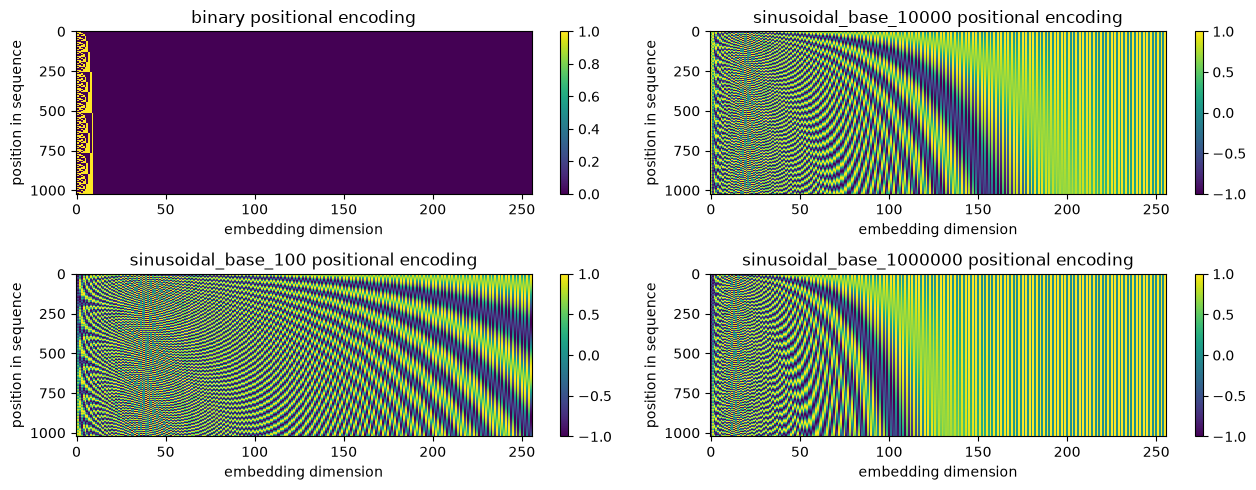

In [82]:
import matplotlib.pyplot as plt 
import numpy as np

max_seq_len, d_embed = 1024, 256

binary = BinaryPositionalEmbeddings(max_seq_len, d_embed).encodings
sinusoidal_base_10000 = SinusoidalEmbeddings(max_seq_len, d_embed, base=10000).encodings
sinusoidal_base_100 = SinusoidalEmbeddings(max_seq_len, d_embed, base=100).encodings
sinusoidal_base_1000000 = SinusoidalEmbeddings(max_seq_len, d_embed, base=1000000).encodings

fig, axes = plt.subplots(2, 2, figsize=(13,5)) # creates subplots of 2 rows, 2 across
axes = axes.flatten()

for ax, enc, title in zip(axes, [binary, sinusoidal_base_10000,sinusoidal_base_100, sinusoidal_base_1000000], ["binary", "sinusoidal_base_10000","sinusoidal_base_100", "sinusoidal_base_1000000"], ): 
	im = ax.imshow(enc, aspect="auto", cmap="viridis", interpolation="nearest")
	ax.set_title(f"{title} positional encoding")
	ax.set_xlabel("embedding dimension")
	ax.set_ylabel("position in sequence")
	fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

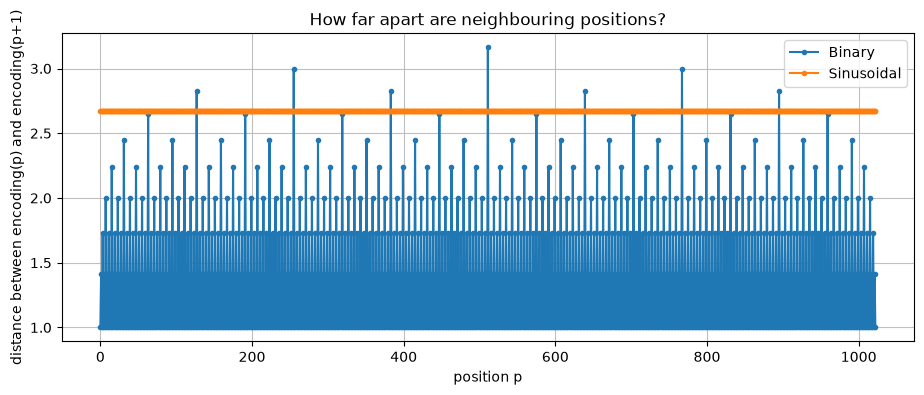

In [ ]:
# creates a [max_seq_len,] array of the differences between p_t+1 - p_t
# .norm() is the square root of the sum of elemnts along the specified dimension
binary_steps = (binary[1:] - binary[:-1]).norm(dim=-1)
sin_steps = (sinusoidal_base_10000[1:] - sinusoidal_base_10000[:-1]).norm(dim=-1) 

plt.figure(figsize=(11, 4))
plt.plot(binary_steps, label="Binary", marker="o", markersize=3)
plt.plot(sin_steps, label="Sinusoidal", marker="o", markersize=3)
plt.xlabel("position p")
plt.ylabel("distance between encoding(p) and encoding(p+1)")
plt.title("How far apart are neighbouring positions?")
plt.legend()
plt.grid(alpha=0.8)
plt.show()

Denoting the cosine similarity between tokens at position i and j

- in the right graph, as j moves away from i, the similarity decreases regardless of the token i's index (i.e. similarity between token 10 and 10,000 is same as token 20 and 10,010)
- left graph just shows similarity between token i, j for different values, obviously the diagonal = 1, since cos( token 1, token 1 ) = 1 as cos0=1

The jumpiness is the nature of sin,cos embeddings which we don't like because the relative distance of a token, 30 tokens away, can be the same as one that is 1 token away. But due to the slow embeddings from 128:256, the model can distinguish!


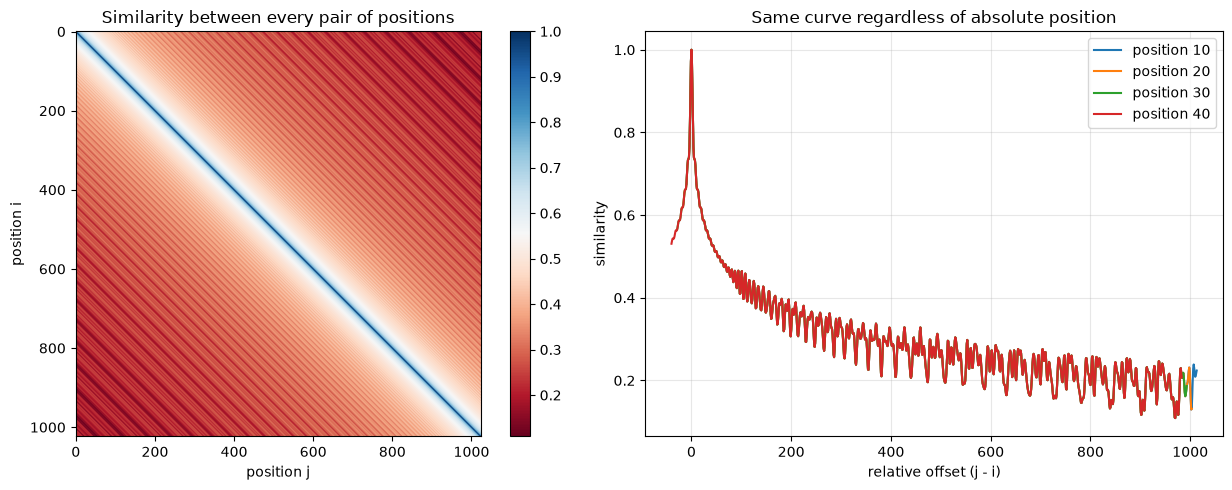

In [ ]:
sin_normed = sinusoidal_base_10000 / sinusoidal_base_10000.norm(dim=-1, keepdim=True)
similarity = sin_normed @ sin_normed.T  # [max_seq_len, max_seq_len]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(similarity, cmap="RdBu")
axes[0].set_title("Similarity between every pair of positions")
axes[0].set_xlabel("position j")
axes[0].set_ylabel("position i")
fig.colorbar(im, ax=axes[0])

# Take a few rows and overlay them, re-centred on their own position
for p in [10, 20, 30, 40]:
    offsets = torch.arange(max_seq_len) - p
    axes[1].plot(offsets, similarity[p], label=f"position {p}") # similarity between tokens at respective offsets
axes[1].set_xlabel("relative offset (j - i)")
axes[1].set_ylabel("similarity")
axes[1].set_title("Same curve regardless of absolute position")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Learned positional embeddings

Instead of computing the position vector with a fixed formula, just make it a lookup table and let gradient descent figure out what each position should look like. This is what GPT-2 and BERT do.

Big problems

- **cannot extrapolate.** The table has exactly `max_seq_len` rows. Position 5000 in a table trained to 1024 simply does not exist — there's no formula to fall back on, unlike sinusoidal.
- **high positions are undertrained.** Most training sequences are short, so row 1000 receives gradient updates far less often than row 5, and its vector stays close to its random initialisation.
- **the distances are arbitrary.** Nothing in the objective forces position 1 and 2 to end up closer together than position 1 and 5000 — any such structure has to be learned from scratch.


In [105]:
class LearnedPositionalEmbedding(nn.Module):
	"""A trainable lookup table: one learned d_model vector per position."""

	def __init__(self, max_seq_len: int, d_embed: int):
		"""
		Args:
			max_seq_len: The maximum sequence length the model supports.
			d_model: The dimension of the embedding vector.
		"""
		super().__init__()
		# Create a lookup table mapping each integer position to a d_model vector
		self.embedding = nn.Embedding(num_embeddings=max_seq_len, embedding_dim=d_embed)

	def forward(self, seq_len: int) -> torch.Tensor:
		"""
		Args:
			seq_len: The current length of the sequence being processed.

		Returns:
			A tensor of shape (seq_len, d_model) containing the learned embeddings.
		"""
		if seq_len > self.embedding.num_embeddings:
			raise ValueError(f"Sequence length {seq_len} exceeds maximum {self.embedding.num_embeddings}")

		# Generate the integer sequence: [0, 1, 2, ..., seq_len - 1]
		# We ensure it is on the same device as the embedding weights
		positions = torch.arange(seq_len, dtype=torch.long, device=self.embedding.weight.device)

		# Look up the trainable embedding vector for each integer position
		return self.embedding(positions)

# --- Example Usage ---

learned_pos_encoder = LearnedPositionalEmbedding(max_seq_len=max_seq_len, d_embed=d_embed)

learned_positional_embeddings = learned_pos_encoder(max_seq_len)
final_embeddings = token_embeddings + learned_positional_embeddings

print(final_embeddings.shape)

# Unlike the integer encoding, this one has parameters to train - and they are
# the reason it can't extrapolate past max_seq_len
n_params = sum(p.numel() for p in learned_pos_encoder.parameters())
print(f"learned params: {n_params:,} ({max_length} positions x {dim} dims)")

torch.Size([32, 1024, 256])
learned params: 262,144 (1024 positions x 256 dims)


## Relative positional embeddings

- using the log or linear distance between the tokens (i.e. log(token_idx_i - token_idx_j))
- add a relative positional embedding bias to the $QK^T$ matrix, before softmaxing - it simply encodes the log distances of every query token from the respective key token
  - $QK^T - w_{\text{relative~distance~penalty}} ~b_{i-j}$
  - using a linear penalty - this becomes exponential with softmax, shrinking how much a token attends to a far away token exponentially

Big problems

- memory bandwidth bound - needing to load a new $n^2$ matrix
- linear decay is too simplistic (as implemented by ALiBi), the further away 2 tokens are
- scales poorly and the log/linear distances explode if you do the penalty at 1M context length.
  - Token i attending to token 1,000,000 will have an very large negative value for the pos embedding
  - basically any tokens far away have an attention weight of zero

KV Cache problems

- very naive implemenations added this bias to the K matrix making KV caching problematic
- newer versions added it to the QK matrix - which was much faster but still bad, because you need to materialize another $n^2$ matrix, and consider what happens when n = 10,000


$$\text{RelativeAttention} = \text{Softmax} \left( \frac{Q K^\top + S_{rel}}{\sqrt{D_h}} \right) V $$

Where $S_{rel}$ is a bias matrix (see the output below)


In [110]:
class RelativePositionalEmbeddings(nn.Module): 

	def __init__(self, max_seq_len: int, d_embed: int): 

		super().__init__()

		self.encodings = (torch.arange(max_seq_len).unsqueeze(1) - torch.arange(max_seq_len).unsqueeze(0)).abs() # (max_seq_len, max_seq_len)
		
	def forward(self, x_in): 

		seq_len = x_in.shape[1]

		return self.encodings[:seq_len, :seq_len] # the shape of the encoding depends 

relative_pos_encoder = RelativePositionalEmbeddings(max_seq_len, d_embed)

print(relative_pos_encoder.encodings[:5, :5])

# this is for use in a self-attention layer

tensor([[0, 1, 2, 3, 4],
        [1, 0, 1, 2, 3],
        [2, 1, 0, 1, 2],
        [3, 2, 1, 0, 1],
        [4, 3, 2, 1, 0]])


## Rotary positional embeddings

Why sinusoidal embeddings are problematic

- word position interaction noise from the word attending to the position vector (we never want this to happen)
- the model learns to ignore this noise but we'd rather just get rid of the additive nature of sinusoidal embeddings, switching to a multiplicative / rotational embedding

$$x_m = e_m + PE_m$$

$$Q_m^T K_n = \underbrace{(W_Q e_m)^T (W_K e_n)}_{\text{Word to Word}} + \underbrace{(W_Q e_m)^T (W_K PE_n)}_{\text{Word to Key-Position}} + \underbrace{(W_Q PE_m)^T (W_K e_n)}_{\text{Query-Position to Word}} + \underbrace{(W_Q PE_m)^T (W_K PE_n)}_{\text{Position to Position}}$$

Why we like RoPE

This is very similar to sinusoidal embeddings so all the work we did to understand that is going to pay off here.

Get this: instead of adding the sinusoidal embeddings, we are instead going to multiply the existing embeddings by them! That's it.

$$Q_m = R_m (W_Q e_m) \quad \text{and} \quad K_n = R_n (W_K e_n)$$

_And multiply!_

$$Q_m^T K_n = (W_Q e_m)^T \mathbf{R_{n-m}} (W_K e_n)$$

- we get the benefit of both fixed and relative positional embeddings
  - now when we dot product 2 vectors together, the angle between them is explicitly the original angle (encoded in the token embedding) + angle from RoPE rotation. This is the benefit of relative embeddings
- we can apply this at every attention layer
  - additive operations were problematic since they increased magnitude, but now, with RoPE, rotations preserve scale!
- easily extrapolates to longer contexts
  - unseen additive sinusoidal embeddings would confuse the model, but now with RoPE, we can just increase frequency and do minimal FT on the model if we want to bump up context length


In [134]:
class RotaryPositionalEmbeddings(nn.Module):

	def __init__(self, max_seq_len: int, d_embed: int, base: int=1e4):

		super().__init__()

		assert d_embed % 2 == 0
		
		position = torch.arange(max_seq_len).unsqueeze(1) # (max_seq_len,1)
		
		pair_index = torch.arange(0, d_embed, 2) # (d_embed//2,)

		inv_freq = torch.exp(-math.log(base) * pair_index / d_embed) # (d_embed//2,)

		angles = position * inv_freq # (max_seq_len, d_embed), since inv_freq will broadcast 

		# # encodings = torch.zeros(max_seq_len, d_embed)
		# encodings[:, 0::2] = torch.sin(angles) 
		# encodings[:, 1::2] = torch.cos(angles)

		sin_angles = torch.sin(angles)
		cos_angles = torch.cos(angles)

		self.register_buffer('sin_angles', sin_angles)
		self.register_buffer('cos_angles', cos_angles)

	def forward(self, x_in): 

		seq_len = x_in.shape[1]
		
		sin = self.sin_angles[:seq_len]
		cos = self.cos_angles[:seq_len]

		x_even, x_odd = x_in[..., 0::2], x_in[..., 1::2] # (B, T, d_embed//2)

		# rotation matrix is R = [[cos -sinx], [sinx, cosx]]

		out_even = x_even * cos - x_odd * sin # (B, T, d_embed//2)
		out_odd = x_even * sin + x_odd * cos # (B, T, d_embed//2)

		return torch.stack((out_even, out_odd),dim=-1).flatten(-2, -1)


def rope_embedding(Q, K, max_seq_len, d_embed): 

	rotary_encodings = RotaryPositionalEmbeddings(max_seq_len, d_embed)
	Q = rotary_encodings(Q) 
	K = rotary_encodings(K)

	scores = Q @ K.transpose(1,2)

	return scores

Q = torch.randn(batch_size, max_seq_len, d_embed)
K = torch.randn(batch_size, max_seq_len, d_embed)

scores = rope_embedding(Q, K, max_seq_len, d_embed)
scores.shape

torch.Size([32, 1024, 1024])

Some quick intuition on how `torch.stack` works

- why is it that when you flatten the last 2 dimensions, it becomes perfectly alternating as we wanted?
- its because you flatten by stacking the vectors along the flattened dimension
  - flatten [[0,1,2,3],[4,5,6,7]] = [0,1,2,3,4,5,6,7]


In [ ]:
torch.manual_seed(32)
x = torch.rand(3,4)
print(x)

y = torch.stack((x,x), dim=-1)
print(y, y.shape)
z = y.flatten(-2,-1)
print(z, z.shape)

tensor([[0.8757, 0.2721, 0.4141, 0.7857],
        [0.1130, 0.5793, 0.6481, 0.0229],
        [0.5874, 0.3254, 0.9485, 0.5219]])
tensor([[[0.8757, 0.8757],
         [0.2721, 0.2721],
         [0.4141, 0.4141],
         [0.7857, 0.7857]],

        [[0.1130, 0.1130],
         [0.5793, 0.5793],
         [0.6481, 0.6481],
         [0.0229, 0.0229]],

        [[0.5874, 0.5874],
         [0.3254, 0.3254],
         [0.9485, 0.9485],
         [0.5219, 0.5219]]]) torch.Size([3, 4, 2])
tensor([[0.8757, 0.8757, 0.2721, 0.2721, 0.4141, 0.4141, 0.7857, 0.7857],
        [0.1130, 0.1130, 0.5793, 0.5793, 0.6481, 0.6481, 0.0229, 0.0229],
        [0.5874, 0.5874, 0.3254, 0.3254, 0.9485, 0.9485, 0.5219, 0.5219]]) torch.Size([3, 8])


**YaRN (yet another Rope Embedding)**

- what do we do if we encouter sequence lengths longer than the ones the model sees in training
  - we need to change the positional embeddings to adapt to the longer sequence lengths, so that they look like embeddings the model recognises!
  - we could just stretch the embeddings but then we'll lose the finer-grain detail of the higher freq dimensions
    - i.e. high freq embeddings change more often for every subsequent token in a sequence, allowing the model to distinguish token 100 from token 101 better

  - so why don't we stretch the low freq ones, leave the high freq ones alone, and stretch the ones in the middle a little bit based on their freq?

- to decide which dimensions are high vs low freq
  - calculate the period of the sin(mx) or cos(mx) curve for a given embedding dim, then find how many times the period repeats in max_seq_len tokens

  - this tells us how many 'cycles' occur across the length of our new max token length sequence
  - if its not a lot of cycles, we stretch (i.e. < beta_low) but if its a lot of cycles, we keep the same (i.e. > beta_fast) - this is because fast cycles are important for granular position information


In [ ]:
# return new angles for RoPE embeddings
def precompute_freqs_cis(qk_rope_head_dim, max_seq_len, beta_fast, beta_slow, base, rope_factor): 

	dim = qk_rope_head_dim

	def find_correction_dim(num_rotations, dim, base, max_seq_len):
		
		# return the embedding dimensions where we would have travelled num_rotations (i.e. done num_rotations periods or cycles) across the max_seq_len radians (i.e. t = max_seq_len)
		return dim * math.log(max_seq_len / (num_rotations * 2 * math.pi)) / (2 * math.log(base)) 

	def find_correction_range(low_rot, high_rot, dim, base, max_seq_len):

		low = math.floor(find_correction_dim(low_rot, dim, base, max_seq_len)) # lowest index that does less than X=low_rot rotations in max_seq_len radians
		high = math.ceil(find_correction_dim(low_rot, dim, base, max_seq_len)) # highest index that does more than X=high_rot rotations in max_seq_len radians

		# low cannot be less than 0 since embedding dims aren't negative
		# similarly the highest index doing very fast rotations can't be > no. of embedding dimensions
		return max(low, 0), min(high, dim-1) 

	def linear_ramp_factor(min, max, dim): 

		# we'll apply a linear ramp of interpolation for indices between the very high rotational freq dimensions vs very low ones

		if min == max: 
			max += 0.001 # this may happen if all are very fast rotational freq (i.e. high_rot) or all are slow (i.e. low_rot), or high_rot = low_rot
		
		linear_func = (torch.arange(dim, dtype=torch.float32) - min) / (max - min) # ramps as moves up the dimensions
		ramp_func = torch.clamp(linear_func, 0, 1) # clamp values (i.e. clipping on both sides) 
		
		return ramp_func # any values below 'beta_slow' will be 0, any above 'beta_fast' will be 1, the rest will be decimals

	inv_freqs = 1.0 / (base ** (torch.arange(0, dim, 2, dtype=torch.float32) / dim)) # (dim//2, ), giving us the pair values for RoPE embedding
	
	if max_seq_len > args.original_seq_len: # we need interpolation
		low, high = find_correction_range(beta_fast, beta_slow, dim, base, args.original_seq_len) # indexes we dont change, indexes we do, and the ones in the middle! 
		smooth = 1 - linear_ramp_factor(low, high, dim//2) 
		
		# low freq that need to be interpolated (i.e. stretched), are divided by a factor, to slow the freq
		# we identify these ones by multiplying by 1-smooth
		# conversely for the ones in the middle, we multiply by their ratios. Middle linearly ramped ones end up being ~ freqs/factor × 0.5  +  freqs × 0.5 (weighted sum)
		inv_freqs = inv_freqs / rope_factor * (1-smooth) + inv_freqs * smooth

	t = torch.arange(max_seq_len)
	freqs = torch.outer(t, freqs) # outer product that produces the full rope matrix, (T, dim//2)
	freqs_cis = torch.polar(torch.ones_like(freqs), freqs) # this is the full vector in polar form since we want every dimension to be unit vectors

	return freqs_cis  # (max_seq_len, dim//2), each index is the complex coordinates of every token's positional embedding

def apply_rotary_emb(x: torch.Tensor, freq_cis: torch.Tensor, interleaved: bool = True):

	dtype = x.dtype
	shape = x.shape

	# apply the rotary embedding to a vector
	x = torch.view_as_complex(x.float().view(*shape[:-1], -1, 2)) # unpacks the shape tuple, then splits the last dimension into 2
	y = torch.view_as_real(x * freq_cis).flatten(-2, -1) # (B, T, d//2) * (T, d//2) <- the final dimension of both is the complex dimension

	return y

**How torch.polar works**

- as you would expect but instead of cartesian, it places into complex coordinates
- input tensor 1xd (abs values for all d complex vectors), angle 1xd (angle values for all d complex vectors)


In [146]:
abs = torch.tensor([1, 2], dtype=torch.float64)
angle = torch.tensor([np.pi / 2, 5 * np.pi / 4], dtype=torch.float64)
z = torch.polar(abs, angle)

# since np.pi is not exactly pi, the answer is basically 0 but not exactly
print(z, 'complex')

z = torch.view_as_real(z)
print(z, 'real')

tensor([ 6.1232e-17+1.0000j, -1.4142e+00-1.4142j], dtype=torch.complex128) complex
tensor([[ 6.1232e-17,  1.0000e+00],
        [-1.4142e+00, -1.4142e+00]], dtype=torch.float64) real


**Quick recap on torch.gather**


In [ ]:
# 1. Logits from your model (Batch Size = 3, Classes = 4)
logits = torch.tensor([
    [1.5, 2.3, -0.4, 0.1],  # Sample 0 logits
    [0.2, 0.5,  3.1, 1.2],  # Sample 1 logits
    [2.8, -1.1, 0.4, 0.9]   # Sample 2 logits
])

# 2. Ground-truth target class indices (Shape: [3])
targets = torch.tensor([1, 2, 0]) 

# 3. Reshape targets to match logits dimensions (Shape becomes [3, 1])
# This satisfies the rule: input and index must have same number of dimensions.
index1 = targets.unsqueeze(dim=1) 
index2 = targets.unsqueeze(dim=0) 

# 4. Gather the target logits along the class dimension (dim=1)
target_logits = torch.gather(input=logits, dim=1, index=index1)
first_logits = torch.gather(input=logits, dim=1, index=index2)

print(target_logits, first_logits)

tensor([[2.3000],
        [3.1000],
        [2.8000]]) tensor([[ 2.3000, -0.4000,  1.5000]])
